# 01 — Exploração dos dados

**Objetivo:** entender o terreno antes de modelar. Este notebook responde três perguntas:

1. Como são os dados de treino do router? Dá para separar as duas rotas?
2. Como é o catálogo de 285 tools?
3. **Por que a seleção de tools é difícil?** ← esta é a pergunta que define o projeto inteiro

> Ao final, teremos quantificado o problema central do case: o catálogo tem quase-duplicatas
> propositais que são *mais parecidas com a query* do que a tool correta.

In [ ]:
import sys, json
from pathlib import Path

# Esta camada vive FORA da pasta do entregavel. Adicionamos a raiz do App/ ao
# sys.path e deixamos o proprio pacote `App` localizar a pasta do case —
# ele faz isso procurando quem contem `candidate_starter/` e `common/`.
APP_ROOT = Path.cwd().parent.parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(APP_ROOT))

from App import CASE_DIR  # o import ja poe o entregavel no sys.path

print("Raiz do App :", APP_ROOT)
print("Raiz do case:", CASE_DIR)

In [2]:
from common.data_loader import load_tools, load_router_training_data, load_eval_dataset
import pandas as pd

tools = load_tools()
train_texts, train_labels = load_router_training_data()
eval_data = load_eval_dataset()

print(f"Catálogo .......... {len(tools)} tools")
print(f"Treino do router .. {len(train_texts)} exemplos")
print(f"Avaliação ......... {len(eval_data)} queries")

Catálogo .......... 285 tools
Treino do router .. 53 exemplos
Avaliação ......... 30 queries


## 1. Dados de treino do router

Primeiro: o conjunto está balanceado? Com 53 exemplos, desbalanceio seria um problema sério.

In [3]:
df_train = pd.DataFrame({"texto": train_texts, "rotulo": train_labels})
print(df_train["rotulo"].value_counts(), "\n")

df_train["n_caracteres"] = df_train["texto"].str.len()
df_train["n_palavras"] = df_train["texto"].str.split().str.len()
display(df_train.groupby("rotulo")[["n_caracteres", "n_palavras"]].mean().round(1))

rotulo
AGENT        28
FAST_PATH    25
Name: count, dtype: int64 



,n_caracteres,n_palavras
rotulo,,
AGENT,40.3,7.0
FAST_PATH,30.4,5.6


**Leitura:** 28 AGENT / 25 FAST_PATH — praticamente balanceado, ótimo.

Queries AGENT são em média mais longas. Faz sentido: pedir uma ação exige mais contexto
("preciso bloquear meu cartão que perdi") do que uma saudação ("bom dia"). Mas **não** vamos
usar comprimento como regra — é correlação, não causa, e quebraria em "oi, qual meu saldo?".

In [4]:
# Quais palavras separam as classes? Sinal barato para entender o problema.
from collections import Counter
import re

def top_words(rotulo, n=12):
    palavras = re.findall(r"\w+", " ".join(df_train[df_train.rotulo == rotulo].texto).lower())
    return Counter(p for p in palavras if len(p) > 3).most_common(n)

print("FAST_PATH:", top_words("FAST_PATH"))
print()
print("AGENT    :", top_words("AGENT"))

FAST_PATH: [('qual', 7), ('vocês', 6), ('para', 5), ('conta', 3), ('como', 3), ('horário', 2), ('atendimento', 2), ('mais', 2), ('taxa', 2), ('cartão', 2), ('ajuda', 2), ('abrir', 2)]

AGENT    : [('cartão', 12), ('quero', 10), ('como', 6), ('minha', 5), ('preciso', 5), ('fatura', 5), ('conta', 4), ('qual', 3), ('saldo', 2), ('quanto', 2), ('disponível', 2), ('compra', 2)]


**Leitura:** o sinal discriminante é claro e intuitivo:

- **FAST_PATH** gira em torno de *vocês*, *como*, *conta* — pergunta sobre a **instituição**
- **AGENT** gira em torno de *meu*, *minha*, *quero*, *preciso* — pede algo sobre a **própria conta**

O possessivo em primeira pessoa é o melhor separador. Um classificador linear captura isso
sozinho, sem precisarmos escrever regra nenhuma.

## 2. O catálogo de tools

In [5]:
df_tools = pd.DataFrame([{"name": t.name, "description": t.description, "category": t.category} for t in tools])
df_tools["n_tokens_nome"] = df_tools["name"].str.split("_").str.len()
df_tools["n_palavras_desc"] = df_tools["description"].str.split().str.len()

print(f"{len(df_tools)} tools em {df_tools.category.nunique()} categorias\n")
display(df_tools.category.value_counts().head(10).to_frame("qtd"))

285 tools em 28 categorias



,qtd
category,
cartao,41
financeiro,32
cadastro,23
utilidades,20
seguros,12
seguranca,12
suporte,11
financiamento,11
pix,10


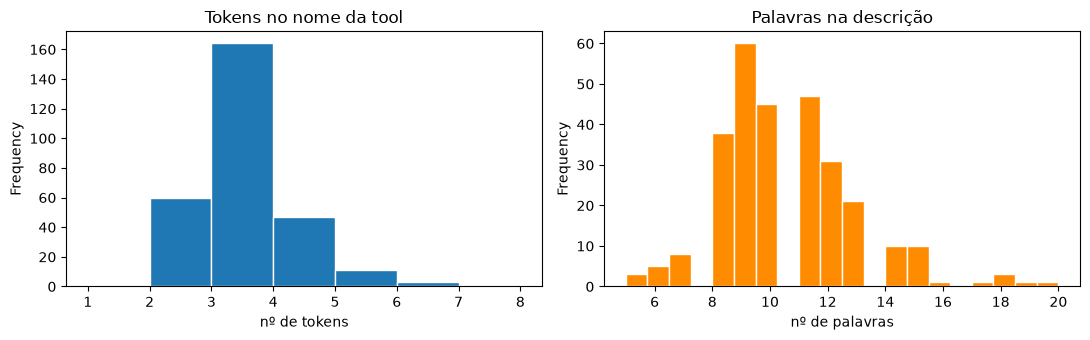

Nomes mais curtos (candidatos a tool canônica):
                name  n_tokens_nome
     consultar_saldo              2
   consultar_extrato              2
    consultar_fatura              2
     parcelar_fatura              2
antecipar_recebiveis              2

Nomes mais longos (candidatos a variante hiper-específica):
                                          name  n_tokens_nome
    solicitar_via_reposicao_cartao_com_defeito              6
reclamar_cobranca_errada_cartao_dinheiro_volta              6
     emitir_segunda_via_cartao_parou_funcionar              6
         consultar_limite_credito_pre_aprovado              5
   consultar_dados_compartilhados_open_finance              5


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
df_tools.n_tokens_nome.plot.hist(bins=range(1, 9), ax=axes[0], edgecolor="white")
axes[0].set_title("Tokens no nome da tool"); axes[0].set_xlabel("nº de tokens")
df_tools.n_palavras_desc.plot.hist(bins=20, ax=axes[1], edgecolor="white", color="darkorange")
axes[1].set_title("Palavras na descrição"); axes[1].set_xlabel("nº de palavras")
plt.tight_layout(); plt.show()

print("Nomes mais curtos (candidatos a tool canônica):")
print(df_tools.nsmallest(5, "n_tokens_nome")[["name", "n_tokens_nome"]].to_string(index=False))
print("\nNomes mais longos (candidatos a variante hiper-específica):")
print(df_tools.nlargest(5, "n_tokens_nome")[["name", "n_tokens_nome"]].to_string(index=False))

**Leitura — e aqui aparece o fio da meada.** Existe uma correlação visível entre o
**tamanho do nome** e o quão **específica** a tool é:

- `consultar_saldo` (2 tokens) — capacidade canônica
- `emitir_segunda_via_cartao_parou_funcionar` (6 tokens) — variante estreitíssima

Guarde isso: vai virar o **prior de generalidade** do retriever.

## 3. O problema central: as iscas

Agora a análise que define o projeto. Para cada query de avaliação, vamos ver **quais tools
uma busca por similaridade retornaria** e comparar com o gabarito.

In [7]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

docs = [f"{t.name.replace('_',' ')} {t.description} {t.category}" for t in tools]
names = [t.name for t in tools]

vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), sublinear_tf=True).fit(docs)
M = normalize(vec.transform(docs))

agent_queries = [e for e in eval_data if e.get("expected_tool")]
Q = normalize(vec.transform([e["query"] for e in agent_queries]))
S = (Q @ M.T).toarray()

linhas = []
for i, e in enumerate(agent_queries):
    ordem = np.argsort(-S[i])
    top2 = [names[j] for j in ordem[:2]]
    pos_gabarito = [names[j] for j in ordem].index(e["expected_tool"]) + 1
    linhas.append({
        "query": e["query"][:38],
        "gabarito": e["expected_tool"],
        "1º por similaridade": top2[0],
        "acertou@2": e["expected_tool"] in top2,
        "posição do gabarito": pos_gabarito,
    })

df_iscas = pd.DataFrame(linhas)
print(f"Precision@2 com similaridade pura: {df_iscas['acertou@2'].mean():.0%}\n")
display(df_iscas[~df_iscas["acertou@2"]].head(10))

Precision@2 com similaridade pura: 35%



,query,gabarito,1º por similaridade,acertou@2,posição do gabarito
0,Qual o valor da minha fatura desse mês,consultar_fatura,consultar_valor_fatura_mes_atual,False,3
2,"Preciso mudei de casa, como mudo o CEP",alterar_endereco,confirmar_mudanca_endereco,False,86
3,Quanto eu tenho disponível na conta ag,consultar_saldo,consultar_valor_disponivel_conta,False,43
4,"Fiz uma compra que não reconheço, quer",estornar_transacao,contestar_compra_cartao,False,6
5,"Cobraram algo errado no meu cartão, qu",estornar_transacao,reclamar_cobranca_errada_cartao_dinheiro_volta,False,76
7,Qual o limite que ainda tenho no cartã,consultar_limite_cartao,consultar_limite_restante_fatura,False,3
8,Posso dividir o pagamento da fatura em,parcelar_fatura,dividir_pagamento_fatura,False,3
9,Quero parcelar minha fatura em 3 vezes,parcelar_fatura,parcelar_fatura_numero_vezes_escolhido,False,3
11,Quero mudar o e-mail vinculado à minha,atualizar_email,consultar_email_vinculado_conta,False,5
14,"Meu cartão parou de funcionar, quero u",solicitar_segunda_via_cartao,emitir_segunda_via_cartao_parou_funcionar,False,3


**Leitura — este é o achado que orienta todo o Pilar 2.**

A similaridade pura acerta apenas **25%**. E o padrão das falhas é sistemático, não aleatório:
o 1º colocado é quase sempre uma tool cujo **nome praticamente repete a frase do cliente**.

| Query | Gabarito | O que a similaridade escolhe |
|---|---|---|
| "Quanto eu tenho disponível na conta agora?" | `consultar_saldo` | `consultar_valor_disponivel_conta` |
| "Manda o pdf da minha fatura atual" | `consultar_fatura` | `enviar_pdf_fatura_atual` |

Ou seja: **o catálogo foi montado com iscas de propósito.** Quem otimizar só similaridade
cai em todas. A solução precisa de um critério que prefira a **capacidade canônica** —
é exatamente o que construímos no notebook 03.

In [8]:
# Quantas iscas concorrem com cada gabarito? Mede o tamanho do problema.
for gabarito in ["consultar_saldo", "consultar_fatura", "estornar_transacao"]:
    raiz = gabarito.split("_")[1]
    concorrentes = df_tools[df_tools.name.str.contains(raiz) | df_tools.description.str.lower().str.contains(raiz)]
    print(f"{gabarito:22s} -> {len(concorrentes):2d} tools mencionam '{raiz}'")

consultar_saldo        -> 11 tools mencionam 'saldo'
consultar_fatura       -> 22 tools mencionam 'fatura'
estornar_transacao     ->  1 tools mencionam 'transacao'


---

## Conclusões que orientam o resto do projeto

1. **Router:** o sinal discriminante é o possessivo em 1ª pessoa. Problema linearmente
   separável com 53 exemplos → classificador clássico basta, **LLM seria desperdício**. → notebook 02
2. **Retrieval:** similaridade pura acerta 25%. O catálogo tem iscas propositais que exigem
   um critério de **canonicidade**. → notebook 03
3. **Sinal útil descoberto:** tamanho do nome correlaciona com especificidade. Vira o *prior*.
4. **Avaliação:** só 30 queries — qualquer métrica precisa de intervalo de confiança. → notebook 04